## Read data

In [1]:
import pandas as pd
import numpy as np

bike_counts_df = pd.read_csv("bike_project_data/bike_counts.csv")
danish_holidays_df = pd.read_csv("bike_project_data/danish_holidays.csv")
weather_copenhagen_df = pd.read_csv("bike_project_data/weather_copenhagen.csv")

df = pd.merge(bike_counts_df, weather_copenhagen_df, on="datetime")

df[["date", "time"]] = df["datetime"].str.split(expand=True)
# df = df.drop("datetime", axis=1)

# convert both to normalized pandas timestamps
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
danish_holidays_df["date"] = pd.to_datetime(danish_holidays_df["date"]).dt.normalize()

holiday_dates = set(danish_holidays_df["date"])
df["holiday"] = df["date"].isin(holiday_dates).astype(int)

df["date"] = pd.to_datetime(df["date"])  # ensure datetime

df["is_weekend"] = df["date"].dt.weekday.isin([5, 6]).astype(int)

# Define workday
df["is_workday"] = ((df["is_weekend"] == 0) & (df["holiday"] == 0)).astype(int)

# Create full timestamp for sorting
df["datetime_full"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime_full").copy()

col = "bike_count"

def fill_nan_same_hour_workdays(group):
    group = group.sort_values("date").copy()
    
    values = group[col].copy()
    
    for i in group.index[group[col].isna()]:
        pos = group.index.get_loc(i)
        
        prev_vals = group.iloc[:pos]
        prev_vals = prev_vals[
            (prev_vals["is_workday"] == 1) & (prev_vals[col].notna())
        ][col].tail(5)
        
        next_vals = group.iloc[pos+1:]
        next_vals = next_vals[
            (next_vals["is_workday"] == 1) & (next_vals[col].notna())
        ][col].head(5)
        
        neighbors = pd.concat([prev_vals, next_vals])
        
        if len(neighbors) > 0:
            values.loc[i] = neighbors.mean()
    
    group[col] = values
    return group  # <- keeps all columns including station/time

parts = []

for (station, time), group in df.groupby(["station", "time"]):
    filled = fill_nan_same_hour_workdays(group)
    parts.append(filled)

df = pd.concat(parts, ignore_index=True)

df.head()

,datetime,station,latitude,longitude,bike_count,temperature_C,wind_speed_ms,precipitation_mm,date,time,holiday,is_weekend,is_workday,datetime_full
0,2021-01-01 00:00:00,Amagerbrogade,55.6627,12.6022,1.0,-2.8,8.7,0.0,2021-01-01,00:00:00,1,0,0,2021-01-01
1,2021-01-02 00:00:00,Amagerbrogade,55.6627,12.6022,1.0,-10.4,13.9,0.0,2021-01-02,00:00:00,0,1,0,2021-01-02
2,2021-01-03 00:00:00,Amagerbrogade,55.6627,12.6022,1.0,-12.8,19.3,0.2,2021-01-03,00:00:00,0,1,0,2021-01-03
3,2021-01-04 00:00:00,Amagerbrogade,55.6627,12.6022,3.0,-5.0,9.1,0.0,2021-01-04,00:00:00,0,0,1,2021-01-04
4,2021-01-05 00:00:00,Amagerbrogade,55.6627,12.6022,3.0,-7.8,9.4,0.0,2021-01-05,00:00:00,0,0,1,2021-01-05


In [52]:
df[df["bike_count"].isna()]

,datetime,station,latitude,longitude,bike_count,temperature_C,wind_speed_ms,precipitation_mm,date,time,holiday,is_weekend,is_workday,datetime_full


### Data split

In [53]:
train_df = df[(df["date"] >= "2021-01-01") & (df["date"] <= "2022-06-30")]
val_df = df[(df["date"] >= "2022-07-01") & (df["date"] <= "2022-12-31")]
test_df = df[df["date"] >= "2023-01-01"]

train_df.shape, val_df.shape, test_df.shape

((78624, 14), (26496, 14), (52560, 14))

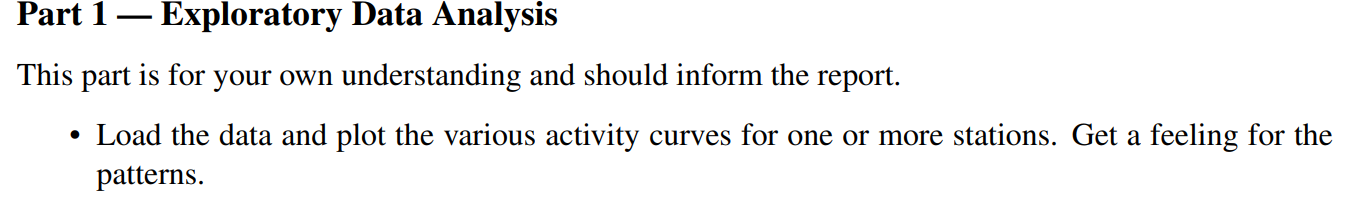

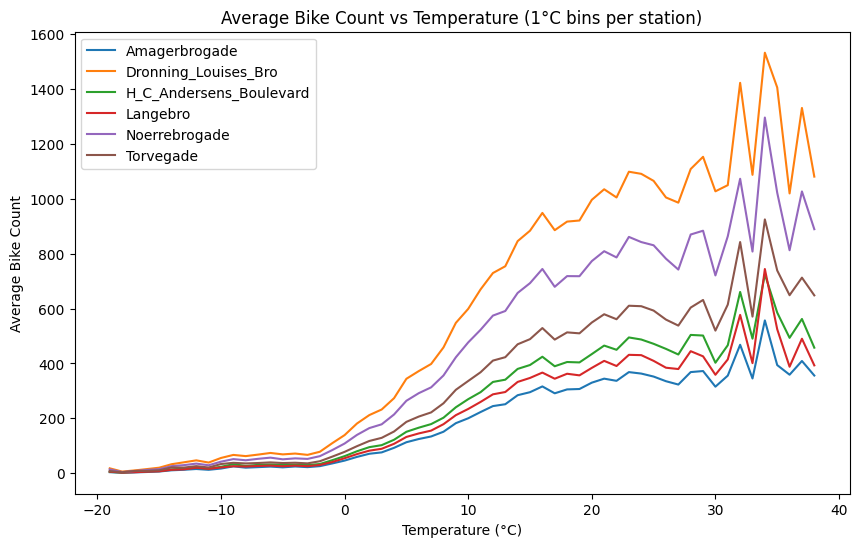

In [64]:
# df[df["station"] == "Dronning_Louises_Bro"].plot("temperature_C" , "bike_count", "scatter", color=df["station"])
# df.plot("temperature_C" , "bike_count", "scatter", color=df["station"])

# df["temp_bin"] = df["temperature_C"].round(0)
df["temp_bin"] = np.floor(df["temperature_C"])

avg_df = (
    df.groupby(["station", "temp_bin"])["bike_count"]
      .mean()
      .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for station, data in avg_df.groupby("station"):
    data = data.sort_values("temp_bin")
    data["bike_count_smooth"] = data["bike_count"].rolling(3, center=True).mean()
    plt.plot(data["temp_bin"], data["bike_count"], label=station)

plt.xlabel("Temperature (°C)")
plt.ylabel("Average Bike Count")
plt.title("Average Bike Count vs Temperature (1°C bins per station)")
plt.legend()
plt.show()

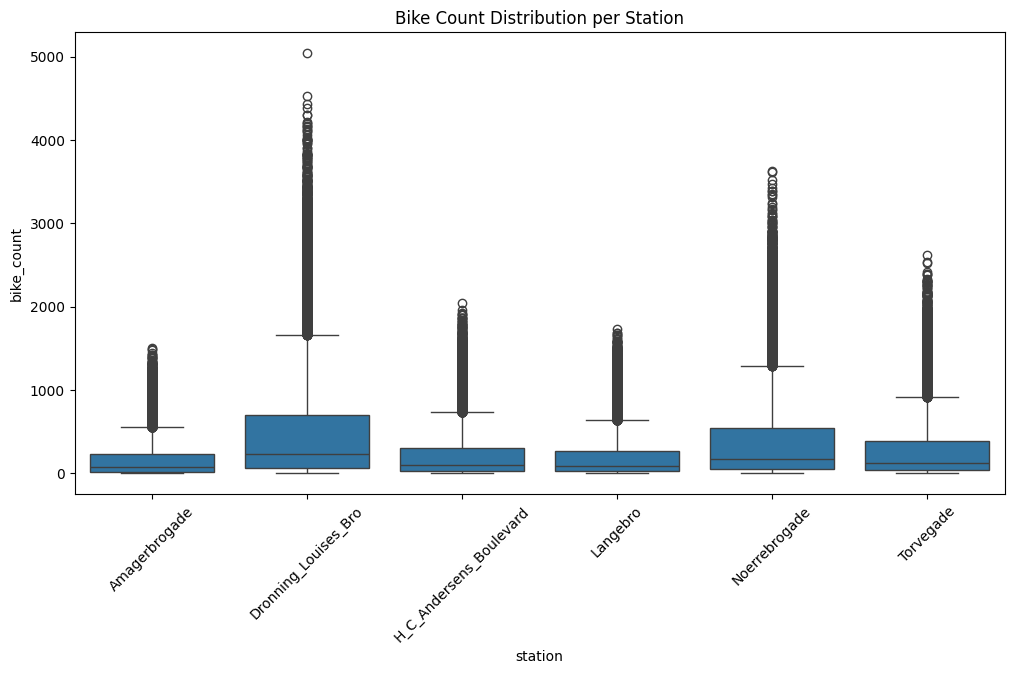

In [59]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="station", y="bike_count")

plt.xticks(rotation=45)
plt.title("Bike Count Distribution per Station")
plt.show()

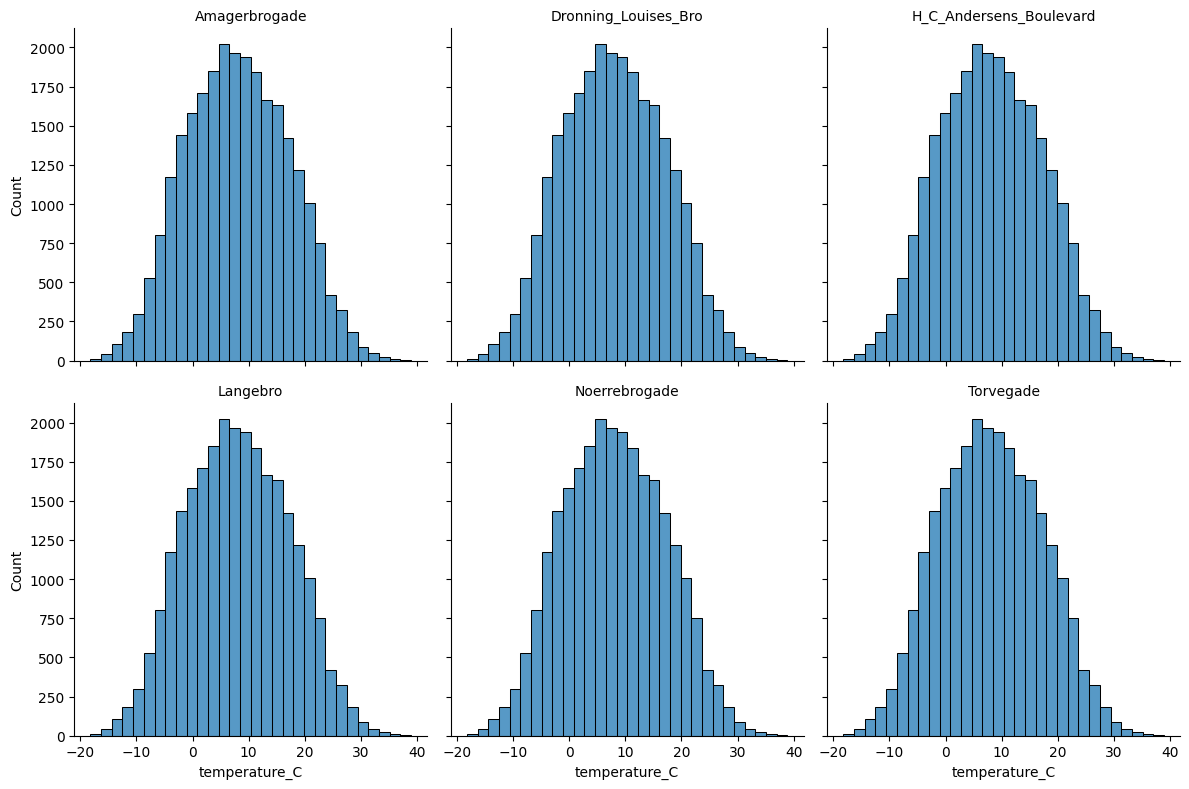

In [57]:
g = sns.FacetGrid(df, col="station", col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x="temperature_C", bins=30)

g.set_titles("{col_name}")

In [ ]:
df[["bike_count", "temperature_C"]].cov()

,bike_count,temperature_C
bike_count,183328.478097,1780.359668
temperature_C,1780.359668,83.008152


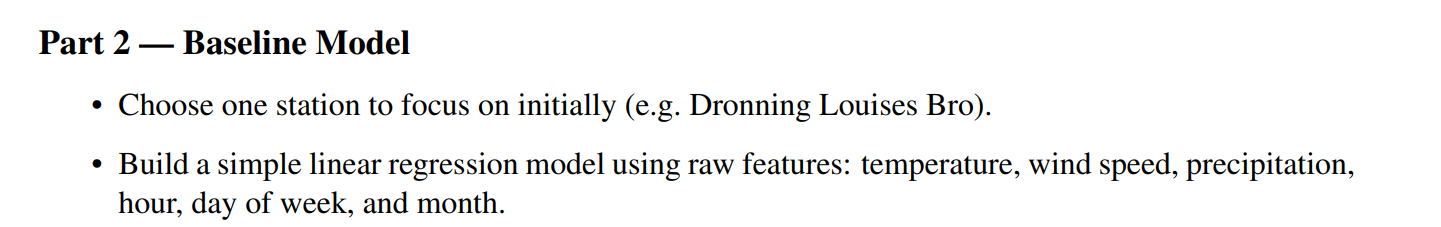

In [72]:
df.columns

Index(['datetime', 'station', 'latitude', 'longitude', 'bike_count',
       'temperature_C', 'wind_speed_ms', 'precipitation_mm', 'date', 'time',
       'holiday', 'is_weekend', 'is_workday', 'datetime_full', 'temp_bin'],
      dtype='str')

In [74]:
X_train = train_df[train_df["station"] == "Dronning_Louises_Bro"]
X_train = X_train["temperature_C", "wind_speed_ms", "precipitation_mm", "time"]

weights = np.linalg.solve(X_train.T@X_train,X.T@y)

KeyError: ('temperature_C', 'wind_speed_ms', 'precipitation_mm', 'time')